# Introduction to Python Project : FoodHub Data Analysis

## Problem Statement
####Context

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. Online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub offers access to multiple restaurants through a single smartphone app.

The app allows restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirms the pick-up in the app and travels to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin on the delivery order from the restaurants.

####Objective

The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience. Suppose you are hired as a Data Scientist in this company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company improve its business.




### Data Dictionary
Data Dictionary

order_id: Unique ID of the order

customer_id: ID of the customer who ordered the food

restaurant_name: Name of the restaurant

cuisine_type: Cuisine ordered by the customer

cost_of_the_order: Cost of the order

day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)

rating: Rating given by the customer out of 5

food_preparation_time: Time (in minutes) taken by the restaurant to prepare the
food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.

delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information


### Let us start by importing the required libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Understanding the structure of the data

In [ ]:

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/foodhub_order.csv')

In [ ]:
df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


### **Question 1:** How many rows and columns are present in the data? [0.5 mark]

In [ ]:
df.shape

(1898, 9)

#### Observations:


### **Question 2:** What are the datatypes of the different columns in the dataset? (The info() function can be used) [0.5 mark]

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


#### Observations:


In [ ]:
#no null values in columns
df.isnull().sum()

,0
order_id,0
customer_id,0
restaurant_name,0
cuisine_type,0
cost_of_the_order,0
day_of_the_week,0
rating,0
food_preparation_time,0
delivery_time,0


### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method. [1 mark]

In [ ]:
#no null values but there some order that not given ratings which is not required
df2=df.copy()
df2

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24
...,...,...,...,...,...,...,...,...,...
1893,1476701,292602,Chipotle Mexican Grill $1.99 Delivery,Mexican,22.31,Weekend,5,31,17
1894,1477421,397537,The Smile,American,12.18,Weekend,5,31,19
1895,1477819,35309,Blue Ribbon Sushi,Japanese,25.22,Weekday,Not given,31,24
1896,1477513,64151,Jack's Wife Freda,Mediterranean,12.18,Weekday,5,23,31


In [ ]:
df2['rating']=df2['rating'].replace(['Not given'],np.nan)
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1162 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


In [ ]:
df2=df2.dropna()
df2['rating']=df2['rating'].astype(int)
df2.info()


<class 'pandas.core.frame.DataFrame'>
Index: 1162 entries, 2 to 1896
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1162 non-null   int64  
 1   customer_id            1162 non-null   int64  
 2   restaurant_name        1162 non-null   object 
 3   cuisine_type           1162 non-null   object 
 4   cost_of_the_order      1162 non-null   float64
 5   day_of_the_week        1162 non-null   object 
 6   rating                 1162 non-null   int64  
 7   food_preparation_time  1162 non-null   int64  
 8   delivery_time          1162 non-null   int64  
dtypes: float64(1), int64(5), object(3)
memory usage: 90.8+ KB


#### Observations:
Droped the orders which is not given and converted object to integer datatype

### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? [2 marks]

In [ ]:
df2.describe()

,order_id,customer_id,cost_of_the_order,rating,food_preparation_time,delivery_time
count,1.162000e+03,1162.000000,1162.000000,1162.000000,1162.000000,1162.000000
mean,1.477520e+06,171939.471601,16.760766,4.344234,27.381239,24.154045
std,5.468713e+02,114551.215031,7.572578,0.741478,4.677922,4.930999
min,1.476547e+06,5139.000000,4.470000,3.000000,20.000000,15.000000
25%,1.477062e+06,77540.000000,12.130000,4.000000,23.000000,20.000000
50%,1.477524e+06,128655.500000,14.600000,5.000000,27.000000,25.000000
75%,1.477992e+06,276066.250000,22.750000,5.000000,32.000000,28.000000
max,1.478444e+06,403019.000000,35.410000,5.000000,35.000000,33.000000


#### Observations:
minimum time taken:20 mins

maximum time take:35 mins

average time take:27.37 mins

### **Question 5:** How many orders are not rated? [1 mark]

In [ ]:
df['rating'].value_counts()

,count
rating,
Not given,736
5,588
4,386
3,188


#### Observations:
There are 736 orders which is not rated

### Exploratory Data Analysis (EDA)

### Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [9 marks]

(array([  0., 100., 200., 300., 400., 500., 600., 700.]),
 [Text(0.0, 0, '0'),
  Text(100.0, 0, '100'),
  Text(200.0, 0, '200'),
  Text(300.0, 0, '300'),
  Text(400.0, 0, '400'),
  Text(500.0, 0, '500'),
  Text(600.0, 0, '600'),
  Text(700.0, 0, '700')])

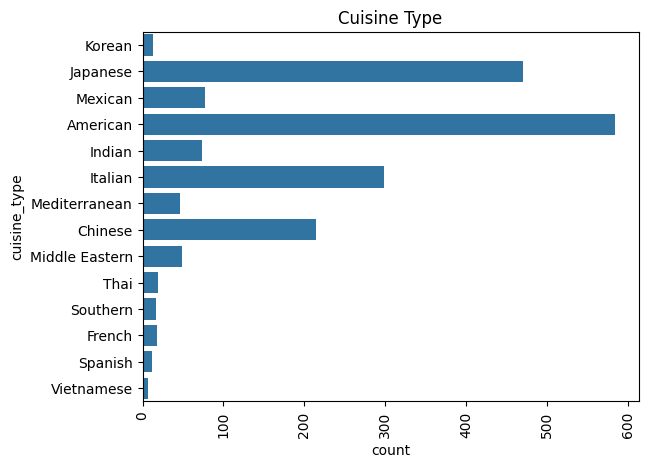

In [ ]:
sns.countplot(df['cuisine_type'])
plt.title('Cuisine Type')
plt.xticks(rotation=90)

Text(0.5, 1.0, 'Cost of the Order')

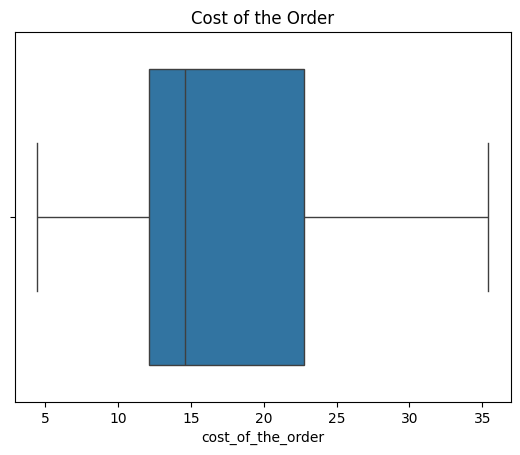

In [ ]:
#analysis using boxplot
sns.boxplot(x=df2['cost_of_the_order'])
plt.title('Cost of the Order')

In [ ]:
df['cost_of_the_order'].describe()

,cost_of_the_order
count,1898.000000
mean,16.498851
std,7.483812
min,4.470000
25%,12.080000
50%,14.140000
75%,22.297500
max,35.410000


Text(0.5, 1.0, 'Day ordered')

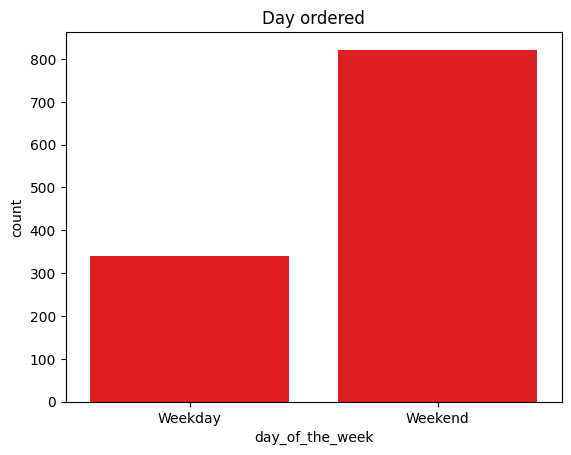

In [ ]:
sns.countplot(x=df2['day_of_the_week'],color='red')
plt.title('Day ordered')

Text(0.5, 1.0, 'Food Preparation Time')

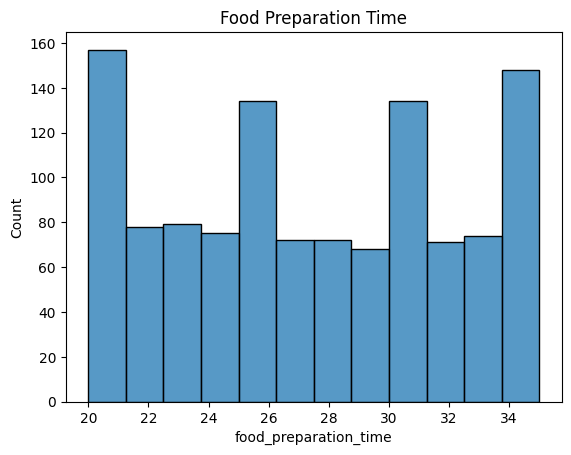

In [ ]:
sns.histplot(df2['food_preparation_time'])
plt.title('Food Preparation Time')

(array([12.5, 15. , 17.5, 20. , 22.5, 25. , 27.5, 30. , 32.5, 35. ]),
 [Text(12.5, 0, '12.5'),
  Text(15.0, 0, '15.0'),
  Text(17.5, 0, '17.5'),
  Text(20.0, 0, '20.0'),
  Text(22.5, 0, '22.5'),
  Text(25.0, 0, '25.0'),
  Text(27.5, 0, '27.5'),
  Text(30.0, 0, '30.0'),
  Text(32.5, 0, '32.5'),
  Text(35.0, 0, '35.0')])

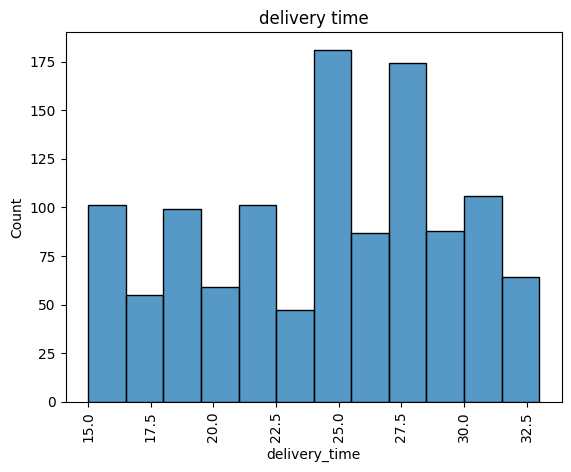

In [ ]:
sns.histplot(df2['delivery_time'])
plt.title('delivery time')
plt.xticks(rotation=90)

### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received? [1 mark]

In [ ]:
df['restaurant_name'].value_counts().head()

,count
restaurant_name,
Shake Shack,219
The Meatball Shop,132
Blue Ribbon Sushi,119
Blue Ribbon Fried Chicken,96
Parm,68


#### Observations:
Top 5 restaurants in terms of the number of orders recieved are:

Shake shack

The Meatball

Blue Ribbon sushi

Blue Ribbon Frird Chicken

Parm

### **Question 8**: Which is the most popular cuisine on weekends? [1 mark]

In [ ]:
df.groupby('day_of_the_week')['cuisine_type'].value_counts()

day_of_the_week  cuisine_type  
Weekday          American          169
                 Japanese          135
                 Italian            91
                 Chinese            52
                 Indian             24
                 Mexican            24
                 Middle Eastern     17
                 Mediterranean      14
                 Southern            6
                 French              5
                 Thai                4
                 Vietnamese          3
                 Korean              2
                 Spanish             1
Weekend          American          415
                 Japanese          335
                 Italian           207
                 Chinese           163
                 Mexican            53
                 Indian             49
                 Mediterranean      32
                 Middle Eastern     32
                 Thai               15
                 French             13
                 Korean             11
                 Southern           11
                 Spanish            11
                 Vietnamese          4
Name: count, dtype: int64

#### Observations:
American cuisine is most popular cuisine in weekends

### **Question 9**: What percentage of the orders cost more than 20 dollars? [2 marks]

In [ ]:
(df['cost_of_the_order']>20).mean()*100

np.float64(29.24130663856691)

#### Observations:
29% of orders more than 20 dollars

### **Question 10**: What is the mean order delivery time? [1 mark]

In [ ]:
df['delivery_time'].mean()

np.float64(24.161749209694417)

#### Observations:
24 mins is the mean delivery time

### **Question 11:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [ ]:
df['customer_id'].value_counts().head()

,count
customer_id,
52832,13
47440,10
83287,9
250494,8
259341,7


#### Observations:
20% discount vouchers will be given to-Customer id's
52832,
47440,
83287

### Multivariate Analysis

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [10 marks]


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13],
 [Text(0, 0, 'Korean'),
  Text(1, 0, 'Japanese'),
  Text(2, 0, 'Mexican'),
  Text(3, 0, 'American'),
  Text(4, 0, 'Indian'),
  Text(5, 0, 'Italian'),
  Text(6, 0, 'Mediterranean'),
  Text(7, 0, 'Chinese'),
  Text(8, 0, 'Middle Eastern'),
  Text(9, 0, 'Thai'),
  Text(10, 0, 'Southern'),
  Text(11, 0, 'French'),
  Text(12, 0, 'Spanish'),
  Text(13, 0, 'Vietnamese')])

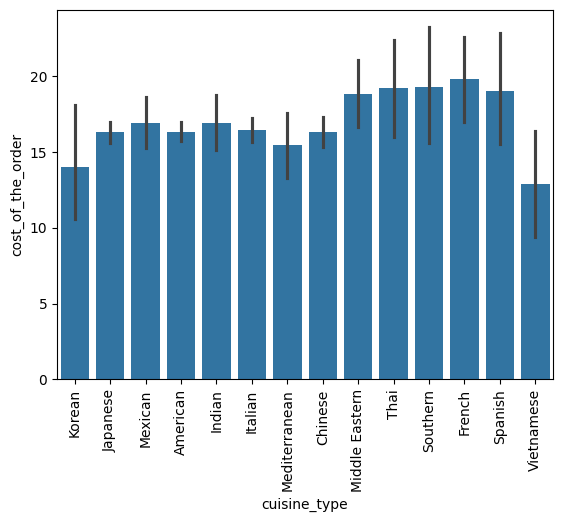

In [ ]:
sns.barplot(x='cuisine_type',y='cost_of_the_order',data=df)
plt.xticks(rotation=90)


Observation:More profit got in french cuisine

<Axes: xlabel='day_of_the_week', ylabel='cost_of_the_order'>

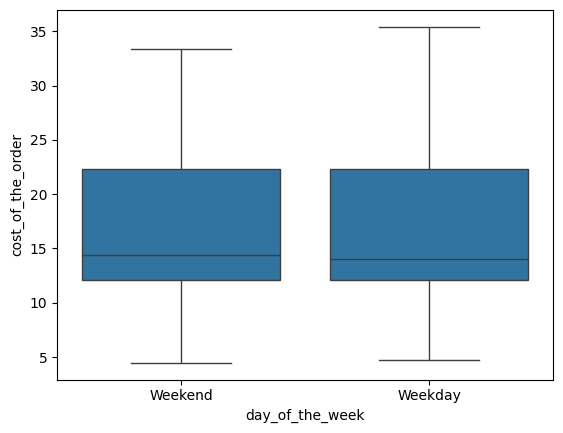

In [ ]:
sns.boxplot(x='day_of_the_week',y='cost_of_the_order',data=df)


<Axes: xlabel='food_preparation_time', ylabel='delivery_time'>

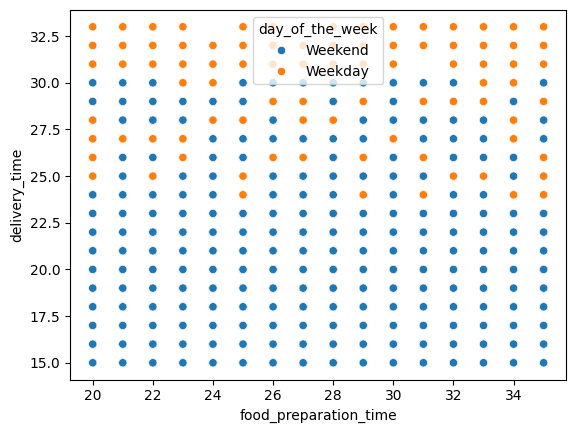

In [ ]:
sns.scatterplot(x='food_preparation_time',y='delivery_time',data=df,hue='day_of_the_week')

Delivery time increases during weekdays

### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer. [3 marks]

In [ ]:
#df2 dataframe already filtered the orders in which rating is not given
#data frame of restaurant have rating more than 50
df3=df2['restaurant_name'].value_counts()>50
df3[df3]


,count
restaurant_name,
Shake Shack,True
The Meatball Shop,True
Blue Ribbon Sushi,True
Blue Ribbon Fried Chicken,True


In [ ]:
#Avg rating more than 4
df4=df2.groupby('restaurant_name')['rating'].mean()>4
df4[df3]

,rating
restaurant_name,
Blue Ribbon Fried Chicken,True
Blue Ribbon Sushi,True
Shake Shack,True
The Meatball Shop,True


#### Observations:
Blue Ribbon fried chicken,Blue ribbon sushi,shakeshack,The Meatball shop restaurants fulfilling the criteria to get the promotional offer.

### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. [3 marks]

In [ ]:
def revenue_cal(cost):
  if cost > 20:
    return cost * 0.25
  elif cost > 5:
    return cost * 0.15
  else:
    return 0
# Apply the function to the column
df['revenue'] = df['cost_of_the_order'].apply(revenue_cal)

# Calculate total revenue
total_revenue = df['revenue'].sum()

total_revenue


np.float64(6166.303)

#### Observations:
Total revenue generated by company is 6166.3


### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.) [2 marks]

In [ ]:
#sum total time taken to deliver and food prep time
df['Total Time']=df['delivery_time']+df['food_preparation_time']
percentage=(df['Total Time']>60).value_counts(normalize=True)[True]*100
percentage


np.float64(10.537407797681771)

#### Observations:
10% of orders takes more than 60 mins

### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? [2 marks]

In [ ]:
mean_delivery = df.groupby('day_of_the_week')['delivery_time'].mean()
mean_delivery


,delivery_time
day_of_the_week,
Weekday,28.340037
Weekend,22.470022


#### Observations:
delivery take more time on week days

### Conclusion and Recommendations

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]

### Conclusions:
*  There are 1898 orders only 1162 gave ratings
*  Most orders are for american cuisine
*  Week days- delivery takes time but less orders on weekdays
*  Shake shack is most preferable resturant
*  52832 given maximum orders
*   Total revenue generated by company is 6166.3







### Recommendations:

*  Delivery time need to be reduced on weekdays
*   Need to provide more offers for top 10 frequent ordering customer
*   Need to tie up with more restaurant which contains American Cuisine
*   Need to give offers on weekdays so that orders will be increased



